# MaNGA-DESI Compact Comparison Figure

This notebook builds figure (2):
- Left column (3 square maps): DESI image, normalized MaNGA Halpha ground truth, normalized projected predicted `halphas_simple`.
- Right column (3 spectra): model prediction + uncertainty and MaNGA spectrum + uncertainty at 3 marked locations.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import zarr
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from urllib.request import urlretrieve
from urllib.request import urlretrieve
from urllib.request import urlretrieve
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from torch.utils.data import DataLoader

repo_root = Path('/pscratch/sd/p/pzehao/MultiModal')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from utils.DataProcessing import MultimodalDataset, get_kernel, smooth_data
from utils.AstroImageFunctions import make_rgb
from models.MAESimple import MaskedAutoencoderViT

ROW_IDX = 2  # same object 
PIX_SCALE = 0.262  # arcsec/pixel
MIN_VALID = 2000

N_SMOOTH_SPEC = 1
# MANUAL_FIBER_OFFSETS_PIX = [(-0.4193,  0.1550), (-26.0, 8.0), (20.0, -35.0)]
MANUAL_FIBER_OFFSETS_PIX = [(-0.4193,  0.1550), (-26.0, 8.0), (23.0, 20.0)]

DESI_ZARR = Path('/pscratch/sd/p/pzehao/iron/desi_maglim_19_5.zarr')
DESI_PARQUET = Path('/pscratch/sd/p/pzehao/iron/desi_zcat_maglim_19_5.parquet')
MATCHES_CSV = Path('/pscratch/sd/p/pzehao/desi_manga_matches.csv')
DRPALL = Path('/pscratch/sd/p/pzehao/MyQuota/drpall-v3_1_1.fits')
MAPS_DIR = Path('/pscratch/sd/p/pzehao/MyQuota/manga_maps')
CUBES_DIR = Path('/pscratch/sd/p/pzehao/MyQuota/manga_cubes')
MAP_DAPTYPE = 'HYB10-MILESHC-MASTARHC2'
CKPT = Path('/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsSimple/epoch=119-val_loss=-1.5850.ckpt')

# HALPHA_SIMPLE_PATH = Path('halphas_simple.npy')
HALPHA_SIMPLE_PATH = Path('/pscratch/sd/p/pzehao/MultiModal/notebooks/halpha_sweep_single_target/halpha_pred_epoch_116.npy')
if not HALPHA_SIMPLE_PATH.exists():
    raise FileNotFoundError('halphas_simple.npy not found. Run manga_tests cell 11 first for this same object.')

def robust_normalize(x):
    x = np.asarray(x, dtype=np.float64)
    out = np.full_like(x, np.nan, dtype=np.float64)
    m = np.isfinite(x)
    if m.sum() < 10:
        return out
    vals = x[m]
    med = np.nanmedian(vals)
    q25, q75 = np.nanpercentile(vals, [25, 75])
    iqr = q75 - q25
    scale = iqr if np.isfinite(iqr) and iqr > 0 else np.nanstd(vals)
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    out[m] = (vals - med) / scale
    return out

def normalize_with_sigma(flux, sigma):
    f = np.isfinite(flux) & np.isfinite(sigma)
    out_f = np.full_like(flux, np.nan, dtype=np.float64)
    out_s = np.full_like(sigma, np.nan, dtype=np.float64)
    if f.sum() < 10:
        return out_f, out_s
    med = np.nanmedian(flux[f])
    if not np.isfinite(med) or abs(med) < 1e-10:
        med = np.nanpercentile(np.abs(flux[f]), 90)
    if not np.isfinite(med) or med <= 0:
        med = 1.0
    out_f[f] = flux[f] / med
    out_s[f] = sigma[f] / abs(med)
    return out_f, out_s

/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Resolve object and load data for the same cross-match flow as manga_tests
desi_tab = pd.read_parquet(DESI_PARQUET, columns=['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'MEAN_FIBER_RA', 'MEAN_FIBER_DEC', 'Z']).copy()
desi_tab['TARGETID'] = desi_tab['TARGETID'].astype(np.int64)
matches_df = pd.read_csv(MATCHES_CSV)
desi_targetids = set(desi_tab['TARGETID'].values)
matches_df = matches_df[matches_df['TARGETID'].isin(desi_targetids)].reset_index(drop=True)
if ROW_IDX < 0 or ROW_IDX >= len(matches_df):
    raise IndexError(f'ROW_IDX={ROW_IDX} out of range [0, {len(matches_df)-1}]')

targetid = int(matches_df.iloc[ROW_IDX]['TARGETID'])
hit = desi_tab.loc[desi_tab['TARGETID'] == targetid]
if hit.empty:
    raise RuntimeError('Selected TARGETID not found in DESI table.')
desi_index = int(hit.index[0])
row = desi_tab.iloc[desi_index]
target_ra = float(row['TARGET_RA'])
target_dec = float(row['TARGET_DEC'])
z_obj = float(row['Z'])

if not DRPALL.exists():
    raise FileNotFoundError(f'Missing DRPALL table: {DRPALL}')
tbl = Table.read(DRPALL, hdu=1)
one_d = [c for c in tbl.colnames if len(tbl[c].shape) <= 1]
manga_df = tbl[one_d].to_pandas()[['plateifu', 'objra', 'objdec']].copy()
manga_df['plateifu'] = manga_df['plateifu'].astype(str)
c1 = SkyCoord([target_ra] * u.deg, [target_dec] * u.deg)
c2 = SkyCoord(manga_df['objra'].to_numpy() * u.deg, manga_df['objdec'].to_numpy() * u.deg)
idx, sep2d, _ = c1.match_to_catalog_sky(c2)
plateifu = manga_df.iloc[int(idx[0])]['plateifu']

plate, ifu = plateifu.split('-')
maps_path = MAPS_DIR / f'manga-{plateifu}-MAPS-{MAP_DAPTYPE}.fits.gz'
cube_path = CUBES_DIR / f'manga-{plateifu}-LOGCUBE.fits.gz'
if not cube_path.exists():
    CUBES_DIR.mkdir(parents=True, exist_ok=True)
    cube_url = f'https://data.sdss.org/sas/dr17/manga/spectro/redux/v3_1_1/{plate}/stack/manga-{plateifu}-LOGCUBE.fits.gz'
    print(f'DEBUG: downloading LOGCUBE from {cube_url}')
    urlretrieve(cube_url, cube_path)
print(f'DEBUG: ROW_IDX={ROW_IDX}, plateifu={plateifu}, maps_exists={maps_path.exists()}, cube_exists={cube_path.exists()}')
if not maps_path.exists() or not cube_path.exists():
    raise FileNotFoundError(f'Missing MAPS/LOGCUBE cache file(s) for {plateifu}. maps={maps_path.exists()}, cube={cube_path.exists()}')

ds = MultimodalDataset(str(DESI_ZARR), start=desi_index, end=desi_index + 1, augment=False, max_shift=0)
batch = next(iter(DataLoader(ds, batch_size=1, shuffle=False)))
img_6ch = batch[4][0].detach().cpu().numpy()
desi_rgb = make_rgb(img_6ch[[0, 1, 3]], 'ls_grz')

with fits.open(maps_path) as h:
    em_hdr = h['EMLINE_GFLUX'].header
    ha_idx = None
    for k, v in em_hdr.items():
        if isinstance(k, str) and k.startswith('C') and isinstance(v, str) and 'ha-6564' in v.lower():
            ha_idx = int(k[1:]) - 1
            break
    if ha_idx is None:
        raise RuntimeError('Could not find Ha-6564 channel in MAPS file.')

    ha_truth = np.asarray(h['EMLINE_GFLUX'].data[ha_idx], dtype=np.float64)
    bad = np.zeros_like(ha_truth, dtype=bool)
    if 'EMLINE_GFLUX_MASK' in h:
        m = np.asarray(h['EMLINE_GFLUX_MASK'].data[ha_idx])
        bad |= (m != 0)
    if 'EMLINE_GFLUX_IVAR' in h:
        iv = np.asarray(h['EMLINE_GFLUX_IVAR'].data[ha_idx], dtype=np.float64)
        bad |= (~np.isfinite(iv)) | (iv <= 0)
    bad |= ~np.isfinite(ha_truth)
    ha_truth[bad] = np.nan

    wcs_map = WCS(h['SPX_MFLUX'].header).celestial

with fits.open(cube_path) as h:
    cube_flux = np.asarray(h['FLUX'].data, dtype=np.float64)
    wave_manga = np.asarray(h['WAVE'].data, dtype=np.float64)
    cube_ivar = np.asarray(h['IVAR'].data, dtype=np.float64) if 'IVAR' in h else None
    cube_mask = np.asarray(h['MASK'].data) if 'MASK' in h else None

ny, nx = ha_truth.shape
iy_grid, ix_grid = np.indices((ny, nx))
ra_grid, dec_grid = wcs_map.pixel_to_world_values(ix_grid.ravel(), iy_grid.ravel())
ra_to_x_sign = -1.0
dec_to_y_sign = -1.0
x_off = (ra_to_x_sign * (ra_grid - target_ra) * np.cos(np.deg2rad(target_dec)) * 3600.0 / PIX_SCALE).reshape(ny, nx)
y_off = (dec_to_y_sign * (dec_grid - target_dec) * 3600.0 / PIX_SCALE).reshape(ny, nx)

halphas_simple = np.load(HALPHA_SIMPLE_PATH).astype(np.float64)
x_src = np.linspace(-63.0, 63.0, halphas_simple.shape[1])
y_src = np.linspace(63.0, -63.0, halphas_simple.shape[0])
xx_src, yy_src = np.meshgrid(x_src, y_src)
valid_src = np.isfinite(halphas_simple)
src_points = np.column_stack([xx_src[valid_src], yy_src[valid_src]])
src_values = halphas_simple[valid_src]
sample_points = np.column_stack([x_off.ravel(), y_off.ravel()])
pred_linear = griddata(src_points, src_values, sample_points, method='linear').reshape(ny, nx)
pred_nearest = griddata(src_points, src_values, sample_points, method='nearest').reshape(ny, nx)
inside_src = (x_off >= x_src.min()) & (x_off <= x_src.max()) & (y_off >= y_src.min()) & (y_off <= y_src.max())
pred_proj = np.where(inside_src, pred_linear, np.nan)
fill = np.isnan(pred_proj) & inside_src
pred_proj[fill] = pred_nearest[fill]
manga_footprint = np.isfinite(ha_truth)
pred_proj = np.where(manga_footprint, pred_proj, np.nan)

truth_n = robust_normalize(ha_truth)
pred_n = robust_normalize(pred_proj)

bad = ~np.isfinite(cube_flux)
if cube_ivar is not None:
    bad |= (~np.isfinite(cube_ivar)) | (cube_ivar <= 0)
if cube_mask is not None:
    bad |= (cube_mask != 0)
valid_counts = np.sum(~bad, axis=0)
inside_desi = (np.abs(x_off) <= 63) & (np.abs(y_off) <= 63)
good = inside_desi & (valid_counts >= MIN_VALID)
if good.sum() < 3:
    good = inside_desi & (valid_counts >= 1200)
if good.sum() < 3:
    raise RuntimeError('Not enough valid MaNGA spaxels for 3 locations.')

yy, xx = np.where(good)
xo = x_off[yy, xx]
yo = y_off[yy, xx]
rr = np.hypot(xo, yo)

manual_offsets = globals().get('MANUAL_FIBER_OFFSETS_PIX', None)
n_smooth_spec = int(globals().get('N_SMOOTH_SPEC', 5))

if manual_offsets is not None:
    req = np.asarray(manual_offsets, dtype=np.float64)
    if req.ndim != 2 or req.shape[1] != 2:
        raise ValueError('MANUAL_FIBER_OFFSETS_PIX must be shape (N,2).')
    if req.shape[0] != 3:
        raise ValueError('Please provide exactly 3 manual fibre offsets.')
    sel = []
    for dx, dy in req:
        d2 = (x_off - dx) ** 2 + (y_off - dy) ** 2
        d2 = np.where(good, d2, np.inf)
        for sx, sy in sel:
            d2[sy, sx] = np.inf
        j = int(np.argmin(d2))
        if not np.isfinite(d2.ravel()[j]):
            raise RuntimeError(f'No valid spaxel near manual offset ({dx:.1f}, {dy:.1f}).')
        yy0, xx0 = np.unravel_index(j, d2.shape)
        sel.append((int(xx0), int(yy0)))
else:
    center_i = int(np.argmin(rr))
    sel = [(int(xx[center_i]), int(yy[center_i]))]
    right = np.where((xo > 8) & (rr > 12))[0]
    left = np.where((xo < -8) & (rr > 12))[0]
    if right.size == 0 or left.size == 0:
        order = np.argsort(-rr)
        for k in order:
            cand = (int(xx[k]), int(yy[k]))
            if cand not in sel:
                sel.append(cand)
            if len(sel) == 3:
                break
    else:
        k1 = right[np.argmax(rr[right])]
        k2 = left[np.argmax(rr[left])]
        sel += [(int(xx[k1]), int(yy[k1])), (int(xx[k2]), int(yy[k2]))]

if len(sel) < 3:
    raise RuntimeError('Could not select 3 distinct locations.')

offsets_pix = np.array([[x_off[y, x], y_off[y, x]] for x, y in sel], dtype=np.float32)

checkpoint = torch.load(CKPT, map_location='cpu')
model = MaskedAutoencoderViT(spec_dim=7781, max_epochs=600, warmup_epoch=5, mask_ratio=0.75,
    embed_dim=256, merged_depth=4, merged_num_heads=8, s_depth=4, e_depth=4,
    s_num_heads=8, e_num_heads=8, decoder_embed_dim=512, decoder_depth=8,
    decoder_num_heads=16, decoder_MLP_coefficient=1,
    patch_scheme={
      'patch_sizes': [1, 1, 2, 4, 8, 16, 32, 64, 128, 64, 32, 16, 8, 4, 2, 1],
      'mask_ratios': [1, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.2, 0.1, 0.0],
      'probs': [0.3] + [0.7/15] * 15
    })
model.load_state_dict(checkpoint['state_dict'], strict=False)
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
x0, spec0, weig0, error0, img0, img_w0, img_e0, z0, xy0 = batch
spec0, weig0, error0 = spec0.to(device), weig0.to(device), error0.to(device)
img0, img_w0, img_e0 = img0.to(device), img_w0.to(device), img_e0.to(device)
z0 = z0.to(device)
xy_batch = torch.tensor(offsets_pix, dtype=xy0.dtype, device=device)

with torch.no_grad():
    model.mask_ratio = 1.0
    model.mask_ratio_img = 0.0
    _, _, _, spec_pred, err_pred, _, _, _ = model.forward(
        spec0.repeat(3, 1), weig0.repeat(3, 1), error0.repeat(3, 1),
        img0.repeat(3, 1, 1, 1), img_w0.repeat(3, 1, 1, 1), img_e0.repeat(3, 1, 1, 1),
        z0.repeat(3), xy_batch
    )

pred_spec = spec_pred.detach().cpu().numpy()
pred_sig = np.exp(err_pred.detach().cpu().numpy())
wave_pred = np.asarray(zarr.open(str(DESI_ZARR), mode='r')['WAVE'][:], dtype=np.float64)
if pred_spec.shape[1] != len(wave_pred):
    off = int(model.left_patches) * int(model.patch_size)
    pred_spec = pred_spec[:, off:off + len(wave_pred)]
    pred_sig = pred_sig[:, off:off + len(wave_pred)]

kernel = get_kernel(n_smooth_spec)
spec_panels = []
for i, (ix, iy) in enumerate(sel):
    m_flux = np.asarray(cube_flux[:, iy, ix], dtype=np.float64)
    if cube_ivar is not None:
        iv = np.asarray(cube_ivar[:, iy, ix], dtype=np.float64)
        m_sig = np.full_like(m_flux, np.nan)
        good_iv = np.isfinite(iv) & (iv > 0)
        m_sig[good_iv] = 1.0 / np.sqrt(iv[good_iv])
    else:
        m_sig = np.full_like(m_flux, np.nan)
    bad_m = ~np.isfinite(m_flux)
    if cube_mask is not None:
        bad_m |= (cube_mask[:, iy, ix] != 0)
    bad_m |= ~np.isfinite(m_sig)
    m_flux[bad_m] = np.nan
    m_sig[bad_m] = np.nan

    p_flux = np.interp(wave_manga, wave_pred, pred_spec[i], left=np.nan, right=np.nan)
    p_sig = np.interp(wave_manga, wave_pred, pred_sig[i], left=np.nan, right=np.nan)

    p_n, p_s = normalize_with_sigma(p_flux, p_sig)
    m_n, m_s = normalize_with_sigma(m_flux, m_sig)
    p_n, p_s = smooth_data(p_n, kernel), smooth_data(p_s, kernel)
    m_n, m_s = smooth_data(m_n, kernel), smooth_data(m_s, kernel)

    spec_panels.append({'wave': wave_manga, 'pred': p_n, 'pred_sig': p_s, 'manga': m_n, 'manga_sig': m_s})

# Replace panel (a) ground truth with the DESI fiber spectrum.
desi_flux_raw = spec0[0].detach().cpu().numpy().astype(np.float64)
desi_sig_raw = error0[0].detach().cpu().numpy().astype(np.float64)
if len(desi_flux_raw) != len(wave_pred):
    off_sp = int(model.left_patches) * int(model.patch_size)
    desi_flux_raw = desi_flux_raw[off_sp:off_sp + len(wave_pred)]
    desi_sig_raw = desi_sig_raw[off_sp:off_sp + len(wave_pred)]
desi_flux_on_manga = np.interp(wave_manga, wave_pred, desi_flux_raw, left=np.nan, right=np.nan)
desi_sig_on_manga = np.interp(wave_manga, wave_pred, desi_sig_raw, left=np.nan, right=np.nan)
desi_n, desi_s = normalize_with_sigma(desi_flux_on_manga, desi_sig_on_manga)
desi_n, desi_s = smooth_data(desi_n, kernel), smooth_data(desi_s, kernel)
spec_panels[0]['manga'] = desi_n
spec_panels[0]['manga_sig'] = desi_s
spec_panels[0]['gt_label'] = 'DESI'

print({'targetid': targetid, 'plateifu': plateifu, 'sep_arcsec': float(sep2d.arcsec[0]), 'locations': offsets_pix.tolist(), 'manual_offsets': manual_offsets, 'smoothing': n_smooth_spec})

DEBUG: ROW_IDX=2, plateifu=8616-9102, maps_exists=True, cube_exists=True


/tmp/ipykernel_2205957/1875542223.py:166: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CKPT, map_location='cpu')


{'targetid': 39627790139533968, 'plateifu': '8616-9102', 'sep_arcsec': 0.006026229634715132, 'locations': [[-0.014635534957051277, -0.022881215438246727], [-26.732213973999023, 7.61071252822876], [22.886146545410156, 19.06110382080078]], 'manual_offsets': [(-0.4193, 0.155), (-26.0, 8.0), (23.0, 20.0)], 'smoothing': 1}


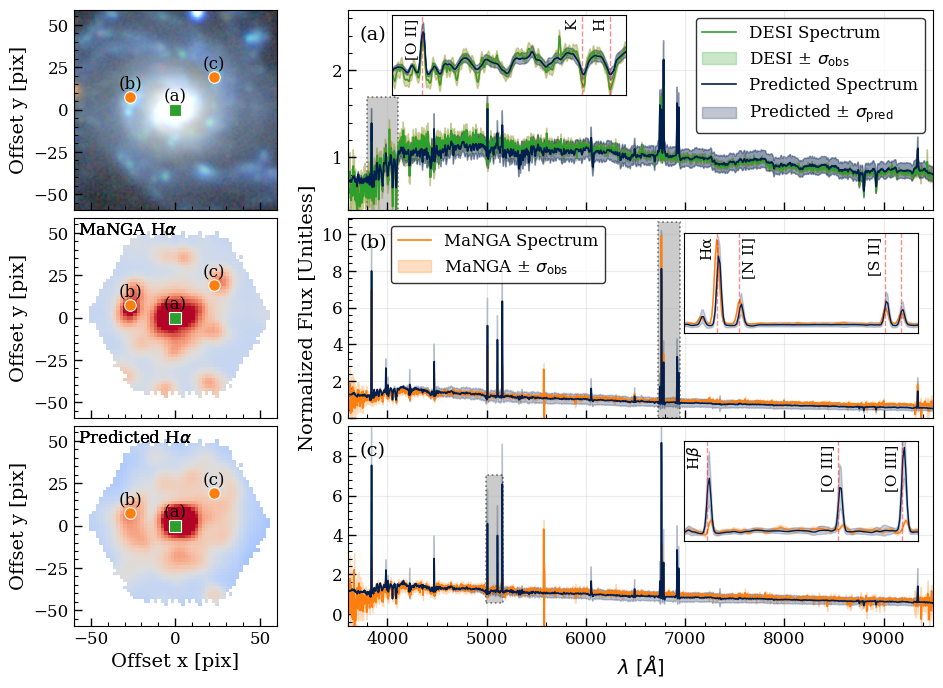

<Figure size 640x480 with 0 Axes>

In [5]:
# Final compact 3x2 figure
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

mpl.rcParams.update({
    'font.family': 'Serif',
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 2, figure=fig, width_ratios=[1.0, 1.7], hspace=0.04, wspace=0.0)

left_axes = [fig.add_subplot(gs[0, 0])]
for i in range(1, 3):
    left_axes.append(fig.add_subplot(gs[i, 0], sharex=left_axes[0], sharey=left_axes[0]))

right_axes = [fig.add_subplot(gs[0, 1])]
for i in range(1, 3):
    right_axes.append(fig.add_subplot(gs[i, 1], sharex=right_axes[0]))

left_xlim = (np.nanmin(x_off) - 4, np.nanmax(x_off) + 4)
left_ylim = (np.nanmin(y_off) - 4, np.nanmax(y_off) + 4)

left_axes[0].imshow(desi_rgb, origin='lower', extent=[*left_xlim, *left_ylim])
left_axes[1].imshow(truth_n, origin='lower', cmap='coolwarm', vmin=-3, vmax=3, extent=[*left_xlim, *left_ylim])
left_axes[2].imshow(pred_n, origin='lower', cmap='coolwarm', vmin=-3, vmax=3, extent=[*left_xlim, *left_ylim])
for ax in left_axes:
    ax.set_xlim(*left_xlim)
    ax.set_ylim(*left_ylim)
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=ax is left_axes[2], direction='in')
left_axes[0].set_ylabel('Offset y [pix]')
left_axes[1].set_ylabel('Offset y [pix]')
left_axes[2].set_ylabel('Offset y [pix]')
left_axes[2].set_xlabel('Offset x [pix]')

for ax in left_axes:
    for (ix, iy), (dx, dy), c, lab in zip(sel, offsets_pix, ['tab:green', 'tab:orange', 'tab:orange'], ['(a)', '(b)', '(c)']):

        marker = 's' if c == 'tab:green' else 'o'
        ax.scatter(dx, dy, s=70, marker=marker, edgecolor='white', facecolor=c, linewidths=0.8)
        ax.text(dx, dy + 5, lab, color='black', ha='center', fontsize=12)
        ax.set_xlim(-60, 60)
        ax.set_ylim(-59, 59)

        if ax is left_axes[1]:
            ax.text(
                0.02, 0.98,                     # position inside panel
                "MaNGA H$\\alpha$",
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=12, color='black'
            )

        if ax is left_axes[2]:
            ax.text(
                0.02, 0.98,                     # position inside panel
                "Predicted H$\\alpha$",
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=12, color='black'
            )

left_yticks = np.arange(-50, 51, 25)
for ax in left_axes:
    ax.set_yticks(left_yticks)
    ax.tick_params(axis='y', labelleft=True, direction='in')

zoom_windows = {
    0: (3800, 4110),
    1: (6730, 6950),
    2: (4990, 5170),
}

# zoom_windows = {
#     0: (3800, 4110),
#     1: (6730, 6950),
#     2: (4400, 0),
# }

# line labels per inset (rest-frame wavelengths in Angstrom).
inset_lines_rest = {
    0: [('[O II]', 3727.4), ('H', 3968.5), ('K', 3933.7)],
    1: [('Hα', 6562.801), ('[N II]', 6583.45), ('[S II]', 6716.44), (' ', 6730.82)],
    2: [('H$\\beta$', 4861.325), ('[O III]', 4958.911), ('[O III]', 5006.843)],
}
panel_labels = ['(a)', '(b)', '(c)']

for i, ax in enumerate(right_axes):
    d = spec_panels[i]
    ax.plot(d['wave'], d['manga'], color='tab:orange', lw=1.2)
    ax.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:orange', alpha=0.25)
    ax.plot(d['wave'], d['pred'], color='#001F4E', lw=1.2)
    ax.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.25)
    ax.set_xlim(3600, 9500)
    # y lim is set to be from 5th percentile of pred and manga to 95th percentile of pred and manga
    all_vals = np.concatenate([d['pred'][np.isfinite(d['pred'])], d['manga'][np.isfinite(d['manga'])]])
    if all_vals.size > 0:
        p5, p95 = np.nanpercentile(all_vals, [0.5, 100])
        ax.set_ylim(p5 - 0.1 * abs(p5), p95 + 0.1 * abs(p95))
    ax.grid(alpha=0.25)
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=i == 2, direction='in')
    ax.tick_params(axis='y', which='both', direction='in')
    ax.set_ylabel('Normalized Flux [Unitless]' if i == 1 else '')
    ax.text(0.02, 0.92, panel_labels[i], transform=ax.transAxes, ha='left', va='top', fontsize=14, color='black')

    x0, x1 = zoom_windows[i]
    if i == 0:
        ax.plot(d['wave'], d['manga'], color='tab:green', lw=1.2)
        ax.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:green', alpha=0.25)
        ax.plot(d['wave'], d['pred'], color='#001F4E', lw=1.2)
        ax.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.25)
        axins = inset_axes(
            ax,
            width='40%',
            height='40%',
            loc='upper left',
            bbox_to_anchor=(0.05, 0.05, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0.9,
        )
        # Legends
        ax.plot([], [], color='tab:green', lw=1.2, label='DESI Spectrum')
        # uncertainty
        ax.fill_between([], [], [], color='tab:green', alpha=0.25, label='DESI ± $\\sigma_\\text{obs}$')
        ax.plot([], [], color='#001F4E', lw=1.2, label='Predicted Spectrum')
        ax.fill_between([], [], [], color='#001F4E', alpha=0.25, label='Predicted ± $\\sigma_\\text{pred}$')
        ax.legend(loc='upper right', fontsize=12, frameon=True, edgecolor='black')
    elif i == 1:
        ax.plot([], [], color='tab:orange', lw=1.2, label='MaNGA Spectrum')
        # uncertainty
        ax.fill_between([], [], [], color='tab:orange', alpha=0.25, label='MaNGA ± $\\sigma_\\text{obs}$')
        ax.legend(
            loc='upper left',
            bbox_to_anchor=(0.06, 1),
            fontsize=12,
            frameon=True,
            edgecolor='black'
        )
        axins = inset_axes(ax, width='40%', height='50%', loc='upper right', borderpad=0.9)
    else:
        axins = inset_axes(ax, width='40%', height='50%', loc='upper right', borderpad=0.9)
    axins.plot(d['wave'], d['manga'], color='tab:orange', lw=1.0)
    axins.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:orange', alpha=0.2)
    axins.plot(d['wave'], d['pred'], color='#001F4E', lw=1.0)
    axins.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.2)
    axins.set_xlim(x0, x1)

    if i == 0:
        axins.plot(d['wave'], d['manga'], color='tab:green', lw=1.0)
        axins.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:green', alpha=0.2)
        axins.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.2)
        axins.plot(d['wave'], d['pred'], color='#001F4E', lw=1.0)
        axins.set_xlim(x0, x1)

    zoom_mask = (d['wave'] >= x0) & (d['wave'] <= x1)
    zoom_vals = np.concatenate([
        d['pred'][zoom_mask & np.isfinite(d['pred'])],
        d['manga'][zoom_mask & np.isfinite(d['manga'])]
    ])
    if zoom_vals.size > 0:
        zmin, zmax = np.nanpercentile(zoom_vals, [1, 100])
        pad = 0.08 * (zmax - zmin) if zmax > zmin else 0.1
        y0, y1 = zmin - pad, zmax + pad
    else:
        y0, y1 = ax.get_ylim()
        y1 = y1 + 1

    if i == 0:
        y0, y1 = 0.3, 1.7
        ax.set_ylim(0.4, 2.7)
        axins.set_ylim(y0, y1)
    else:
        axins.set_ylim(y0, y1)

    # Mark requested lines inside each inset using observed-frame wavelengths.
    x_shift = 0.012 * (x1 - x0)
    ytxt = y0 + 0.96 * (y1 - y0)
    for j, (lab, w_rest) in enumerate(inset_lines_rest[i]):
        w_obs = w_rest * (1.0 + float(z_obj))
        if x0 <= w_obs <= x1:
            axins.axvline(w_obs, color='red', lw=1, ls='--', alpha=0.45)
            x_text = w_obs - x_shift
            ha_text = 'right'
            if lab == '[N II]':
                x_text = w_obs + x_shift
                ha_text = 'left'
            axins.text(x_text, ytxt, lab, rotation=90, fontsize=11, color='black', ha=ha_text, va='top')
            # if i == 0 and lab == '[Ne III]':
            #     axins.text(w_obs, ytxt - 0.08 * (y1 - y0), '3727', rotation=90, fontsize=10, color='black', ha='center', va='top')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Draw the exact zoom region on the parent axis.
    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        facecolor='0.6',
        edgecolor='black',
        linestyle=':',
        linewidth=1.2,
        alpha=0.5,
        zorder=0.5,
    )
    ax.add_patch(rect)

    axins.set_xticks([])
    axins.set_yticks([])

right_axes[2].set_xlabel('$\\lambda$ $[Å]$')

for ax in left_axes + right_axes:
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))  # 4 minor ticks per major
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(which='major', length=6, width=1.0, direction='in')
    ax.tick_params(which='minor', length=3, width=0.8, direction='in')
plt.show()
plt.savefig('IFU.png', dpi=300, bbox_inches='tight')

In [80]:
# # -*- coding: utf-8 -*-
# # Comma-separated entries
# # List of emission lines for prospect viewer
# # Sources: 
# #   - SDSS spZline files ($IDLSPEC2D_DIR/etc/emlines.par, wavelengths in air for lambda > 2000, vacuum for lambda < 2000); 
# #   - A. Edge list (sent by email to T. Davis, 07/04/2020); 
# #   - desisim recombination/forbidden line lists (J. Moustakas; selected those whose quoted line-ratio wrt Hbeta is > 0.1);
# #   - V. Fawcett ([NeIV] and CII], email 30/08/2022, from VI of reddened QSO);
# #   - few others.
# # name,longname,lambda,vacuum,major
# Lyα,Lyman α,1215.67,True,True
# C IV,C IV 1549,1549.48,True,True
# C III],C III] 1908,1908.734,True,True
# Mg II,Mg II 2796,2796.3543,False,True
# Mg II,Mg II 2803,2803.5315,False,True
# [O II],[O II] 3725,3726.032,False,True
# [O II],[O II] 3727,3728.815,False,True
# [Ne III],[Ne III] 3868,3868.76,False,True
# Hδ,Balmer δ,4101.734,False,True
# Hγ,Balmer γ,4340.464,False,True
# Hβ,Balmer β,4861.325,False,True
# [O III],[O III] 4959,4958.911,False,True
# [O III],[O III] 5007,5006.843,False,True
# Hα,Balmer α,6562.801,False,True
# [N II],[N II] 6583,6583.45,False,True
# [S II],[S II] 6716,6716.44,False,True
# [S II],[S II] 6730,6730.82,False,True

# -*- coding: utf-8 -*-
# Comma-separated entries
# List of absorption lines for prospect viewer
# Sources: 
#   - SDSS spZline files ($IDLSPEC2D_DIR/etc/emlines.par, wavelengths in air for lambda > 2000, vacuum for lambda < 2000);
#   - A. Edge list (sent by email to T. Davis, 07/04/2020);
#   - desisim recombination/forbidden line lists (J. Moustakas; selected those whose quoted line-ratio wrt Hbeta is > 0.1); 
#   - few others.
# name,longname,lambda,vacuum,major
# K,K (Ca II 3933),3933.7,False,True
# H,H (Ca II 3968),3968.5,False,True
# G,G (Ca I 4307),4307.74,False,True
# Mg I,Mg I 5175,5175.0,False,True
# D2,D2 (Na I 5889),5889.95,False,True
# D1,D1 (Na I 5895),5895.92,False,True

In [125]:
# MaNGA compact comparison figure for plateifu 9042-9101
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import zarr
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from urllib.request import urlretrieve
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from torch.utils.data import DataLoader

repo_root = Path('/pscratch/sd/p/pzehao/MultiModal')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from utils.DataProcessing import MultimodalDataset, get_kernel, smooth_data
from utils.AstroImageFunctions import make_rgb
from models.MAESimple import MaskedAutoencoderViT
from train.eval_halpha_checkpoint_sweep import build_model, extract_halpha_fast_batch, load_target_context

TARGET_PLATEIFU = '9042-9101'
PIX_SCALE = 0.262  # arcsec/pixel
MIN_VALID = 2000

N_SMOOTH_SPEC = 1
MANUAL_FIBER_OFFSETS_PIX = [(0.5535, -0.1310), (-26.0, 20.0), (2.0, -30.0)]

DESI_ZARR = Path('/pscratch/sd/p/pzehao/iron/desi_maglim_19_5.zarr')
DESI_PARQUET = Path('/pscratch/sd/p/pzehao/iron/desi_zcat_maglim_19_5.parquet')
MATCHES_CSV = Path('/pscratch/sd/p/pzehao/desi_manga_matches.csv')
DRPALL = Path('/pscratch/sd/p/pzehao/MyQuota/drpall-v3_1_1.fits')
MAPS_DIR = Path('/pscratch/sd/p/pzehao/MyQuota/manga_maps')
CUBES_DIR = Path('/pscratch/sd/p/pzehao/MyQuota/manga_cubes')
MAP_DAPTYPE = 'HYB10-MILESHC-MASTARHC2'
CKPT = Path('/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsSimple/epoch=119-val_loss=-1.5850.ckpt')
HALPHA_SOURCE_CKPT = Path('/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsSimple/epoch=116-val_loss=-1.5598.ckpt')
HALPHA_CACHE_DIR = Path('/pscratch/sd/p/pzehao/MultiModal/notebooks/halpha_sweep_9042_9101')
HALPHA_SIMPLE_PATH = HALPHA_CACHE_DIR / 'halpha_pred_epoch_116.npy'


def robust_normalize(x):
    x = np.asarray(x, dtype=np.float64)
    out = np.full_like(x, np.nan, dtype=np.float64)
    m = np.isfinite(x)
    if m.sum() < 10:
        return out
    vals = x[m]
    med = np.nanmedian(vals)
    q25, q75 = np.nanpercentile(vals, [25, 75])
    iqr = q75 - q25
    scale = iqr if np.isfinite(iqr) and iqr > 0 else np.nanstd(vals)
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    out[m] = (vals - med) / scale
    return out


def normalize_with_sigma(flux, sigma):
    f = np.isfinite(flux) & np.isfinite(sigma)
    out_f = np.full_like(flux, np.nan, dtype=np.float64)
    out_s = np.full_like(sigma, np.nan, dtype=np.float64)
    if f.sum() < 10:
        return out_f, out_s
    med = np.nanmedian(flux[f])
    if not np.isfinite(med) or abs(med) < 1e-10:
        med = np.nanpercentile(np.abs(flux[f]), 90)
    if not np.isfinite(med) or med <= 0:
        med = 1.0
    out_f[f] = flux[f] / med
    out_s[f] = sigma[f] / abs(med)
    return out_f, out_s


# Resolve the requested plateifu using the same cross-match table as the notebook.
desi_tab = pd.read_parquet(DESI_PARQUET, columns=['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'MEAN_FIBER_RA', 'MEAN_FIBER_DEC', 'Z']).copy()
desi_tab['TARGETID'] = desi_tab['TARGETID'].astype(np.int64)
matches_df = pd.read_csv(MATCHES_CSV)
desi_targetids = set(desi_tab['TARGETID'].values)
matches_df = matches_df[matches_df['TARGETID'].isin(desi_targetids)].reset_index(drop=True)
row_candidates = matches_df.index[matches_df['plateifu'] == TARGET_PLATEIFU].tolist()
if not row_candidates:
    raise RuntimeError(f'Could not find plateifu {TARGET_PLATEIFU} in matches table.')
ROW_IDX = int(row_candidates[0])

ctx = load_target_context(extractor := __import__('train.eval_halpha_checkpoint_sweep', fromlist=['PairExtractor']).PairExtractor(), str(MATCHES_CSV), ROW_IDX)

# Pull the same target-level variables used by the existing plotting code.
targetid = int(ctx['targetid'])
target_ra = float(ctx['target_ra'])
target_dec = float(ctx['target_dec'])
z_obj = float(ctx['z_obj'])
plateifu = str(ctx['plateifu'])
desi_index = int(ctx['desi_index'])
batch = ctx['batch']
truth_ha = np.asarray(ctx['truth'], dtype=np.float64)
coords = np.asarray(ctx['coords'], dtype=np.float32)
yx_pairs = np.asarray(ctx['yx_pairs'], dtype=np.int32)

plate, ifu = plateifu.split('-')
maps_path = MAPS_DIR / f'manga-{plateifu}-MAPS-{MAP_DAPTYPE}.fits.gz'
cube_path = CUBES_DIR / f'manga-{plateifu}-LOGCUBE.fits.gz'
if not cube_path.exists():
    CUBES_DIR.mkdir(parents=True, exist_ok=True)
    cube_url = f'https://data.sdss.org/sas/dr17/manga/spectro/redux/v3_1_1/{plate}/stack/manga-{plateifu}-LOGCUBE.fits.gz'
    print(f'DEBUG: downloading LOGCUBE from {cube_url}')
    urlretrieve(cube_url, cube_path)
print(f'DEBUG: ROW_IDX={ROW_IDX}, plateifu={plateifu}, maps_exists={maps_path.exists()}, cube_exists={cube_path.exists()}')
if not maps_path.exists() or not cube_path.exists():
    raise FileNotFoundError(f'Missing MAPS/LOGCUBE cache file(s) for {plateifu}. maps={maps_path.exists()}, cube={cube_path.exists()}')

# DESI RGB image from the same loader path as before.
ds = MultimodalDataset(str(DESI_ZARR), start=desi_index, end=desi_index + 1, augment=False, max_shift=0)
batch = next(iter(DataLoader(ds, batch_size=1, shuffle=False)))
img_6ch = batch[4][0].detach().cpu().numpy()
desi_rgb = make_rgb(img_6ch[[0, 1, 3]], 'ls_grz')

with fits.open(maps_path) as h:
    em_hdr = h['EMLINE_GFLUX'].header
    ha_idx = None
    for k, v in em_hdr.items():
        if isinstance(k, str) and k.startswith('C') and isinstance(v, str) and 'ha-6564' in v.lower():
            ha_idx = int(k[1:]) - 1
            break
    if ha_idx is None:
        raise RuntimeError('Could not find Ha-6564 channel in MAPS file.')

    ha_truth = np.asarray(h['EMLINE_GFLUX'].data[ha_idx], dtype=np.float64)
    bad = np.zeros_like(ha_truth, dtype=bool)
    if 'EMLINE_GFLUX_MASK' in h:
        m = np.asarray(h['EMLINE_GFLUX_MASK'].data[ha_idx])
        bad |= (m != 0)
    if 'EMLINE_GFLUX_IVAR' in h:
        iv = np.asarray(h['EMLINE_GFLUX_IVAR'].data[ha_idx], dtype=np.float64)
        bad |= (~np.isfinite(iv)) | (iv <= 0)
    bad |= ~np.isfinite(ha_truth)
    ha_truth[bad] = np.nan
    wcs_map = WCS(h['SPX_MFLUX'].header).celestial

ny, nx = ha_truth.shape
iy_grid, ix_grid = np.indices((ny, nx))
ra_grid, dec_grid = wcs_map.pixel_to_world_values(ix_grid.ravel(), iy_grid.ravel())
ra_to_x_sign = -1.0
dec_to_y_sign = -1.0
x_off = (ra_to_x_sign * (ra_grid - target_ra) * np.cos(np.deg2rad(target_dec)) * 3600.0 / PIX_SCALE).reshape(ny, nx)
y_off = (dec_to_y_sign * (dec_grid - target_dec) * 3600.0 / PIX_SCALE).reshape(ny, nx)

# Generate the target-specific cached Halpha map once, using the fast GPU path.
if not HALPHA_SIMPLE_PATH.exists():
    HALPHA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    map_model = build_model().to(device)
    checkpoint = torch.load(HALPHA_SOURCE_CKPT, map_location='cpu')
    map_model.load_state_dict(checkpoint['state_dict'], strict=False)
    map_model.eval()
    x0, spec0, weig0, error0, img0, img_w0, img_e0, z0, xy0 = batch
    spec0 = spec0.to(device)
    weig0 = weig0.to(device)
    error0 = error0.to(device)
    img0 = img0.to(device)
    img_w0 = img_w0.to(device)
    img_e0 = img_e0.to(device)
    z0 = z0.to(device)
    wave_obs = np.asarray(zarr.open(str(DESI_ZARR), mode='r')['WAVE'][:], dtype=np.float64)
    out_map = np.full_like(ha_truth, np.nan, dtype=np.float64)
    with torch.inference_mode():
        n_coords = coords.shape[0]
        for start in range(0, n_coords, 1024):
            end = min(start + 1024, n_coords)
            bsz = end - start
            xy_chunk = torch.as_tensor(coords[start:end], dtype=xy0.dtype, device=device)
            spec_b = spec0.expand(bsz, -1)
            weig_b = weig0.expand(bsz, -1)
            error_b = error0.expand(bsz, -1)
            img_b = img0.expand(bsz, -1, -1, -1)
            img_w_b = img_w0.expand(bsz, -1, -1, -1)
            img_e_b = img_e0.expand(bsz, -1, -1, -1)
            z_b = z0.expand(bsz)
            _, _, _, spec_pred, _, _, _, _ = map_model.forward(
                spec_b, weig_b, error_b, img_b, img_w_b, img_e_b, z_b, xy_chunk
            )
            pred_np = spec_pred.detach().cpu().numpy()
            hvals = extract_halpha_fast_batch(
                pred_np,
                wave_obs=wave_obs,
                z_obj=z_obj,
                left_patches=map_model.left_patches,
                patch_size=map_model.patch_size,
            )
            loc = yx_pairs[start:end]
            out_map[loc[:, 0], loc[:, 1]] = hvals
    np.save(HALPHA_SIMPLE_PATH, out_map)


DEBUG: ROW_IDX=244, plateifu=9042-9101, maps_exists=True, cube_exists=True


In [126]:
halphas_simple = np.load(HALPHA_SIMPLE_PATH).astype(np.float64)
x_src = np.linspace(-63.0, 63.0, halphas_simple.shape[1])
y_src = np.linspace(63.0, -63.0, halphas_simple.shape[0])
xx_src, yy_src = np.meshgrid(x_src, y_src)
valid_src = np.isfinite(halphas_simple)
src_points = np.column_stack([xx_src[valid_src], yy_src[valid_src]])
src_values = halphas_simple[valid_src]
sample_points = np.column_stack([x_off.ravel(), y_off.ravel()])
pred_linear = griddata(src_points, src_values, sample_points, method='linear').reshape(ny, nx)
pred_nearest = griddata(src_points, src_values, sample_points, method='nearest').reshape(ny, nx)
inside_src = (x_off >= x_src.min()) & (x_off <= x_src.max()) & (y_off >= y_src.min()) & (y_off <= y_src.max())
pred_proj = np.where(inside_src, pred_linear, np.nan)
fill = np.isnan(pred_proj) & inside_src
pred_proj[fill] = pred_nearest[fill]
manga_footprint = np.isfinite(ha_truth)
pred_proj = np.where(manga_footprint, pred_proj, np.nan)

truth_n = robust_normalize(ha_truth)
pred_n = robust_normalize(pred_proj)

bad = ~np.isfinite(batch[1].detach().cpu().numpy().astype(np.float64))
cube_flux = None
with fits.open(cube_path) as h:
    cube_flux = np.asarray(h['FLUX'].data, dtype=np.float64)
    wave_manga = np.asarray(h['WAVE'].data, dtype=np.float64)
    cube_ivar = np.asarray(h['IVAR'].data, dtype=np.float64) if 'IVAR' in h else None
    cube_mask = np.asarray(h['MASK'].data) if 'MASK' in h else None

bad = ~np.isfinite(cube_flux)
if cube_ivar is not None:
    bad |= (~np.isfinite(cube_ivar)) | (cube_ivar <= 0)
if cube_mask is not None:
    bad |= (cube_mask != 0)
valid_counts = np.sum(~bad, axis=0)
inside_desi = (np.abs(x_off) <= 63) & (np.abs(y_off) <= 63)
good = inside_desi & (valid_counts >= MIN_VALID)
if good.sum() < 3:
    good = inside_desi & (valid_counts >= 1200)
if good.sum() < 3:
    raise RuntimeError('Not enough valid MaNGA spaxels for 3 locations.')

yy, xx = np.where(good)
xo = x_off[yy, xx]
yo = y_off[yy, xx]
rr = np.hypot(xo, yo)

manual_offsets = globals().get('MANUAL_FIBER_OFFSETS_PIX', None)
n_smooth_spec = int(globals().get('N_SMOOTH_SPEC', 5))

if manual_offsets is not None:
    req = np.asarray(manual_offsets, dtype=np.float64)
    if req.ndim != 2 or req.shape[1] != 2:
        raise ValueError('MANUAL_FIBER_OFFSETS_PIX must be shape (N,2).')
    if req.shape[0] != 3:
        raise ValueError('Please provide exactly 3 manual fibre offsets.')
    sel = []
    for dx, dy in req:
        d2 = (x_off - dx) ** 2 + (y_off - dy) ** 2
        d2 = np.where(good, d2, np.inf)
        for sx, sy in sel:
            d2[sy, sx] = np.inf
        j = int(np.argmin(d2))
        if not np.isfinite(d2.ravel()[j]):
            raise RuntimeError(f'No valid spaxel near manual offset ({dx:.1f}, {dy:.1f}).')
        yy0, xx0 = np.unravel_index(j, d2.shape)
        sel.append((int(xx0), int(yy0)))
else:
    center_i = int(np.argmin(rr))
    sel = [(int(xx[center_i]), int(yy[center_i]))]
    right = np.where((xo > 8) & (rr > 12))[0]
    left = np.where((xo < -8) & (rr > 12))[0]
    if right.size == 0 or left.size == 0:
        order = np.argsort(-rr)
        for k in order:
            cand = (int(xx[k]), int(yy[k]))
            if cand not in sel:
                sel.append(cand)
            if len(sel) == 3:
                break
    else:
        k1 = right[np.argmax(rr[right])]
        k2 = left[np.argmax(rr[left])]
        sel += [(int(xx[k1]), int(yy[k1])), (int(xx[k2]), int(yy[k2]))]

if len(sel) < 3:
    raise RuntimeError('Could not select 3 distinct locations.')

offsets_pix = np.array([[x_off[y, x], y_off[y, x]] for x, y in sel], dtype=np.float32)

checkpoint = torch.load(CKPT, map_location='cpu')
model = MaskedAutoencoderViT(spec_dim=7781, max_epochs=600, warmup_epoch=5, mask_ratio=0.75,
    embed_dim=256, merged_depth=4, merged_num_heads=8, s_depth=4, e_depth=4,
    s_num_heads=8, e_num_heads=8, decoder_embed_dim=512, decoder_depth=8,
    decoder_num_heads=16, decoder_MLP_coefficient=1,
    patch_scheme={
      'patch_sizes': [1, 1, 2, 4, 8, 16, 32, 64, 128, 64, 32, 16, 8, 4, 2, 1],
      'mask_ratios': [1, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.2, 0.1, 0.0],
      'probs': [0.3] + [0.7/15] * 15
    })
model.load_state_dict(checkpoint['state_dict'], strict=False)
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
x0, spec0, weig0, error0, img0, img_w0, img_e0, z0, xy0 = batch
spec0, weig0, error0 = spec0.to(device), weig0.to(device), error0.to(device)
img0, img_w0, img_e0 = img0.to(device), img_w0.to(device), img_e0.to(device)
z0 = z0.to(device)
xy_batch = torch.tensor(offsets_pix, dtype=xy0.dtype, device=device)

with torch.no_grad():
    model.mask_ratio = 1.0
    model.mask_ratio_img = 0.0
    _, _, _, spec_pred, err_pred, _, _, _ = model.forward(
        spec0.repeat(3, 1), weig0.repeat(3, 1), error0.repeat(3, 1),
        img0.repeat(3, 1, 1, 1), img_w0.repeat(3, 1, 1, 1), img_e0.repeat(3, 1, 1, 1),
        z0.repeat(3), xy_batch
    )

pred_spec = spec_pred.detach().cpu().numpy()
pred_sig = np.exp(err_pred.detach().cpu().numpy())
wave_pred = np.asarray(zarr.open(str(DESI_ZARR), mode='r')['WAVE'][:], dtype=np.float64)
if pred_spec.shape[1] != len(wave_pred):
    off = int(model.left_patches) * int(model.patch_size)
    pred_spec = pred_spec[:, off:off + len(wave_pred)]
    pred_sig = pred_sig[:, off:off + len(wave_pred)]

kernel = get_kernel(n_smooth_spec)
spec_panels = []
for i, (ix, iy) in enumerate(sel):
    m_flux = np.asarray(cube_flux[:, iy, ix], dtype=np.float64)
    if cube_ivar is not None:
        iv = np.asarray(cube_ivar[:, iy, ix], dtype=np.float64)
        m_sig = np.full_like(m_flux, np.nan)
        good_iv = np.isfinite(iv) & (iv > 0)
        m_sig[good_iv] = 1.0 / np.sqrt(iv[good_iv])
    else:
        m_sig = np.full_like(m_flux, np.nan)
    bad_m = ~np.isfinite(m_flux)
    if cube_mask is not None:
        bad_m |= (cube_mask[:, iy, ix] != 0)
    bad_m |= ~np.isfinite(m_sig)
    m_flux[bad_m] = np.nan
    m_sig[bad_m] = np.nan

    p_flux = np.interp(wave_manga, wave_pred, pred_spec[i], left=np.nan, right=np.nan)
    p_sig = np.interp(wave_manga, wave_pred, pred_sig[i], left=np.nan, right=np.nan)

    p_n, p_s = normalize_with_sigma(p_flux, p_sig)
    m_n, m_s = normalize_with_sigma(m_flux, m_sig)
    p_n, p_s = smooth_data(p_n, kernel), smooth_data(p_s, kernel)
    m_n, m_s = smooth_data(m_n, kernel), smooth_data(m_s, kernel)

    spec_panels.append({'wave': wave_manga, 'pred': p_n, 'pred_sig': p_s, 'manga': m_n, 'manga_sig': m_s})

# Replace panel (a) ground truth with the DESI fiber spectrum.
desi_flux_raw = spec0[0].detach().cpu().numpy().astype(np.float64)
desi_sig_raw = error0[0].detach().cpu().numpy().astype(np.float64)
if len(desi_flux_raw) != len(wave_pred):
    off_sp = int(model.left_patches) * int(model.patch_size)
    desi_flux_raw = desi_flux_raw[off_sp:off_sp + len(wave_pred)]
    desi_sig_raw = desi_sig_raw[off_sp:off_sp + len(wave_pred)]
desi_flux_on_manga = np.interp(wave_manga, wave_pred, desi_flux_raw, left=np.nan, right=np.nan)
desi_sig_on_manga = np.interp(wave_manga, wave_pred, desi_sig_raw, left=np.nan, right=np.nan)
desi_n, desi_s = normalize_with_sigma(desi_flux_on_manga, desi_sig_on_manga)
desi_n, desi_s = smooth_data(desi_n, kernel), smooth_data(desi_s, kernel)
spec_panels[0]['manga'] = desi_n
spec_panels[0]['manga_sig'] = desi_s
spec_panels[0]['gt_label'] = 'DESI'

print({'targetid': targetid, 'plateifu': plateifu, 'sep_arcsec': float(ctx['sep_arcsec']), 'locations': offsets_pix.tolist(), 'manual_offsets': manual_offsets, 'smoothing': n_smooth_spec})

# Final compact 3x2 figure
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

mpl.rcParams.update({
    'font.family': 'Serif',
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 2, figure=fig, width_ratios=[1.0, 1.7], hspace=0.04, wspace=0.0)

left_axes = [fig.add_subplot(gs[0, 0])]
for i in range(1, 3):
    left_axes.append(fig.add_subplot(gs[i, 0], sharex=left_axes[0], sharey=left_axes[0]))

right_axes = [fig.add_subplot(gs[0, 1])]
for i in range(1, 3):
    right_axes.append(fig.add_subplot(gs[i, 1], sharex=right_axes[0]))

left_xlim = (np.nanmin(x_off) - 4, np.nanmax(x_off) + 4)
left_ylim = (np.nanmin(y_off) - 4, np.nanmax(y_off) + 4)

left_axes[0].imshow(desi_rgb, origin='lower', extent=[*left_xlim, *left_ylim])
left_axes[1].imshow(truth_n, origin='lower', cmap='coolwarm', vmin=-3, vmax=3, extent=[*left_xlim, *left_ylim])
left_axes[2].imshow(pred_n, origin='lower', cmap='coolwarm', vmin=-3, vmax=3, extent=[*left_xlim, *left_ylim])
for ax in left_axes:
    ax.set_xlim(*left_xlim)
    ax.set_ylim(*left_ylim)
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=ax is left_axes[2], direction='in')
left_axes[0].set_ylabel('Offset y [pix]')
left_axes[1].set_ylabel('Offset y [pix]')
left_axes[2].set_ylabel('Offset y [pix]')
left_axes[2].set_xlabel('Offset x [pix]')

for ax in left_axes:
    for (ix, iy), (dx, dy), c, lab in zip(sel, offsets_pix, ['tab:green', 'tab:orange', 'tab:orange'], ['(a)', '(b)', '(c)']):
        marker = 's' if c == 'tab:green' else 'o'
        ax.scatter(dx, dy, s=70, marker=marker, edgecolor='white', facecolor=c, linewidths=0.8)
        ax.text(dx, dy + 5, lab, color='black', ha='center', fontsize=12)
        ax.set_xlim(-60, 60)
        ax.set_ylim(-59, 59)

        if ax is left_axes[1]:
            ax.text(
                0.02, 0.98,
                'MaNGA H$\\alpha$',
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=12, color='black'
            )

        if ax is left_axes[2]:
            ax.text(
                0.02, 0.98,
                'Predicted H$\\alpha$',
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=12, color='black'
            )

left_yticks = np.arange(-50, 51, 25)
for ax in left_axes:
    ax.set_yticks(left_yticks)
    ax.tick_params(axis='y', labelleft=True, direction='in')

zoom_windows = {
    0: (3900, 4300),
    1: (7000, 7250),
    2: (5150, 5400),
}

inset_lines_rest = {
    0: [('[O II]', 3727.4), ('H', 3968.5), ('K', 3933.7)],
    1: [('Hα', 6562.801), ('[N II]', 6583.45), ('[S II]', 6716.44), (' ', 6730.82)],
    2: [('H$\\beta$', 4861.325), ('[O III]', 4958.911), ('[O III]', 5006.843)],
}
panel_labels = ['(a)', '(b)', '(c)']

for i, ax in enumerate(right_axes):
    d = spec_panels[i]
    ax.plot(d['wave'], d['manga'], color='tab:orange', lw=1.2)
    ax.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:orange', alpha=0.25)
    ax.plot(d['wave'], d['pred'], color='#001F4E', lw=1.2)
    ax.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.25)
    ax.set_xlim(3600, 9500)
    all_vals = np.concatenate([d['pred'][np.isfinite(d['pred'])], d['manga'][np.isfinite(d['manga'])]])
    if all_vals.size > 0:
        p5, p95 = np.nanpercentile(all_vals, [0.5, 100])
        ax.set_ylim(p5 - 0.1 * abs(p5), p95 + 0.1 * abs(p95))
    ax.grid(alpha=0.25)
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=i == 2, direction='in')
    ax.tick_params(axis='y', which='both', direction='in')
    ax.set_ylabel('Normalized Flux [Unitless]' if i == 1 else '')
    ax.text(0.02, 0.92, panel_labels[i], transform=ax.transAxes, ha='left', va='top', fontsize=14, color='black')

    x0, x1 = zoom_windows[i]
    if i == 0:
        ax.plot(d['wave'], d['manga'], color='tab:green', lw=1.2)
        ax.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:green', alpha=0.25)
        ax.plot(d['wave'], d['pred'], color='#001F4E', lw=1.2)
        ax.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.25)
        axins = inset_axes(
            ax,
            width='40%',
            height='40%',
            loc='upper left',
            bbox_to_anchor=(0.05, 0.05, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0.9,
        )
        ax.plot([], [], color='tab:green', lw=1.2, label='DESI Spectrum')
        ax.fill_between([], [], [], color='tab:green', alpha=0.25, label='DESI ± $\\sigma_\\text{obs}$')
        ax.plot([], [], color='#001F4E', lw=1.2, label='Predicted Spectrum')
        ax.fill_between([], [], [], color='#001F4E', alpha=0.25, label='Predicted ± $\\sigma_\\text{pred}$')
        ax.legend(loc='upper right', fontsize=11, frameon=True, edgecolor='black')
    elif i == 1:
        ax.plot([], [], color='tab:orange', lw=1.2, label='MaNGA Spectrum')
        ax.fill_between([], [], [], color='tab:orange', alpha=0.25, label='MaNGA ± $\\sigma_\\text{obs}$')
        ax.legend(
            loc='upper right',
            # bbox_to_anchor=(0.06, 1),
            fontsize=11,
            frameon=True,
            edgecolor='black'
        )
        axins = inset_axes(ax, width='40%', height='50%', loc='upper left', borderpad=0.9, bbox_to_anchor=(0.05, 0.05, 1, 1),
            bbox_transform=ax.transAxes)
    else:
        axins = inset_axes(ax, width='40%', height='50%', loc='upper left', borderpad=0.9, bbox_to_anchor=(0.05, 0.05, 1, 1),
            bbox_transform=ax.transAxes)
    axins.plot(d['wave'], d['manga'], color='tab:orange', lw=1.0)
    axins.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:orange', alpha=0.2)
    axins.plot(d['wave'], d['pred'], color='#001F4E', lw=1.0)
    axins.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.2)
    axins.set_xlim(x0, x1)

    if i == 0:
        axins.plot(d['wave'], d['manga'], color='tab:green', lw=1.0)
        axins.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:green', alpha=0.2)
        axins.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.2)
        axins.plot(d['wave'], d['pred'], color='#001F4E', lw=1.0)
        axins.set_xlim(x0, x1)

    zoom_mask = (d['wave'] >= x0) & (d['wave'] <= x1)
    zoom_vals = np.concatenate([
        d['pred'][zoom_mask & np.isfinite(d['pred'])],
        d['manga'][zoom_mask & np.isfinite(d['manga'])]
    ])
    if zoom_vals.size > 0:
        zmin, zmax = np.nanpercentile(zoom_vals, [1, 100])
        pad = 0.08 * (zmax - zmin) if zmax > zmin else 0.1
        y0, y1 = zmin - pad, zmax + pad
    else:
        y0, y1 = ax.get_ylim()
        y1 = y1 + 1

    if i == 0:
        y0, y1 = 0.1, 1.0
        ax.set_ylim(0.2, 2.6)
        axins.set_ylim(y0, y1)
    else:
        axins.set_ylim(y0, y1)

    x_shift = 0.012 * (x1 - x0)
    ytxt = y0 + 0.96 * (y1 - y0)
    for j, (lab, w_rest) in enumerate(inset_lines_rest[i]):
        w_obs = w_rest * (1.0 + float(z_obj))
        if x0 <= w_obs <= x1:
            axins.axvline(w_obs, color='red', lw=1, ls='--', alpha=0.45)
            x_text = w_obs - x_shift
            ha_text = 'right'
            if lab == '[N II]':
                x_text = w_obs + x_shift
                ha_text = 'left'
            axins.text(x_text, ytxt, lab, rotation=90, fontsize=11, color='black', ha=ha_text, va='top')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        facecolor='0.6',
        edgecolor='black',
        linestyle=':',
        linewidth=1.2,
        alpha=0.5,
        zorder=0.5,
    )
    ax.add_patch(rect)

    axins.set_xticks([])
    axins.set_yticks([])

right_axes[2].set_xlabel('$\\lambda$ $[Å]$')

for ax in left_axes + right_axes:
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.tick_params(which='major', length=6, width=1.0, direction='in')
    ax.tick_params(which='minor', length=3, width=0.8, direction='in')

plt.show()
plt.savefig('IFU_9042-9101.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_746477/2827308694.py:90: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CKPT, map_location='cpu')


{'targetid': 39628444518058848, 'plateifu': '9042-9101', 'sep_arcsec': 0.09025388453166183, 'locations': [[-0.1864207535982132, -0.28649792075157166], [-26.90361976623535, 20.706130981445312], [1.7220180034637451, -30.820871353149414]], 'manual_offsets': [(0.5535, -0.131), (-26.0, 20.0), (2.0, -30.0)], 'smoothing': 1}


In [ ]:
# Full-square variant: predicted Halpha is not masked to the MaNGA footprint
pred_full = np.where(inside_src, pred_linear, pred_nearest)
pred_full_n = robust_normalize(pred_full)

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 2, figure=fig, width_ratios=[1.0, 1.7], hspace=0.04, wspace=0.0)

left_axes = [fig.add_subplot(gs[0, 0])]
for i in range(1, 3):
    left_axes.append(fig.add_subplot(gs[i, 0], sharex=left_axes[0], sharey=left_axes[0]))

right_axes = [fig.add_subplot(gs[0, 1])]
for i in range(1, 3):
    right_axes.append(fig.add_subplot(gs[i, 1], sharex=right_axes[0]))

left_xlim = (np.nanmin(x_off) - 4, np.nanmax(x_off) + 4)
left_ylim = (np.nanmin(y_off) - 4, np.nanmax(y_off) + 4)

left_axes[0].imshow(desi_rgb, origin='lower', extent=[*left_xlim, *left_ylim])
left_axes[1].imshow(truth_n, origin='lower', cmap='coolwarm', vmin=-3, vmax=3, extent=[*left_xlim, *left_ylim])
left_axes[2].imshow(pred_full_n, origin='lower', cmap='coolwarm', vmin=-3, vmax=3, extent=[*left_xlim, *left_ylim])
for ax in left_axes:
    ax.set_xlim(*left_xlim)
    ax.set_ylim(*left_ylim)
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=ax is left_axes[2], direction='in')
left_axes[0].set_ylabel('Offset y [pix]')
left_axes[1].set_ylabel('Offset y [pix]')
left_axes[2].set_ylabel('Offset y [pix]')
left_axes[2].set_xlabel('Offset x [pix]')

for ax in left_axes:
    for (ix, iy), (dx, dy), c, lab in zip(sel, offsets_pix, ['tab:green', 'tab:orange', 'tab:orange'], ['(a)', '(b)', '(c)']):
        marker = 's' if c == 'tab:green' else 'o'
        ax.scatter(dx, dy, s=70, marker=marker, edgecolor='white', facecolor=c, linewidths=0.8)
        ax.text(dx, dy + 5, lab, color='black', ha='center', fontsize=12)
        ax.set_xlim(-60, 60)
        ax.set_ylim(-59, 59)

        if ax is left_axes[1]:
            ax.text(
                0.02, 0.98,
                'MaNGA H$\\alpha$',
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=12, color='black'
            )

        if ax is left_axes[2]:
            ax.text(
                0.02, 0.98,
                'Predicted H$\\alpha$',
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=12, color='black'
            )

left_yticks = np.arange(-50, 51, 25)
for ax in left_axes:
    ax.set_yticks(left_yticks)
    ax.tick_params(axis='y', labelleft=True, direction='in')

zoom_windows = {
    0: (3800, 4110),
    1: (6730, 6950),
    2: (4990, 5170),
}

inset_lines_rest = {
    0: [('[O II]', 3727.4), ('H', 3968.5), ('K', 3933.7)],
    1: [('Hα', 6562.801), ('[N II]', 6583.45), ('[S II]', 6716.44), (' ', 6730.82)],
    2: [('H$\\beta$', 4861.325), ('[O III]', 4958.911), ('[O III]', 5006.843)],
}
panel_labels = ['(a)', '(b)', '(c)']

for i, ax in enumerate(right_axes):
    d = spec_panels[i]
    ax.plot(d['wave'], d['manga'], color='tab:orange', lw=1.2)
    ax.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:orange', alpha=0.25)
    ax.plot(d['wave'], d['pred'], color='#001F4E', lw=1.2)
    ax.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.25)
    ax.set_xlim(3600, 9500)
    all_vals = np.concatenate([d['pred'][np.isfinite(d['pred'])], d['manga'][np.isfinite(d['manga'])]])
    if all_vals.size > 0:
        p5, p95 = np.nanpercentile(all_vals, [0.5, 100])
        ax.set_ylim(p5 - 0.1 * abs(p5), p95 + 0.1 * abs(p95))
    ax.grid(alpha=0.25)
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=i == 2, direction='in')
    ax.tick_params(axis='y', which='both', direction='in')
    ax.set_ylabel('Normalized Flux [Unitless]' if i == 1 else '')
    ax.text(0.02, 0.92, panel_labels[i], transform=ax.transAxes, ha='left', va='top', fontsize=14, color='black')

    x0, x1 = zoom_windows[i]
    if i == 0:
        ax.plot(d['wave'], d['manga'], color='tab:green', lw=1.2)
        ax.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:green', alpha=0.25)
        ax.plot(d['wave'], d['pred'], color='#001F4E', lw=1.2)
        ax.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.25)
        axins = inset_axes(
            ax,
            width='40%',
            height='40%',
            loc='upper left',
            bbox_to_anchor=(0.05, 0.05, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0.9,
        )
        ax.plot([], [], color='tab:green', lw=1.2, label='DESI Spectrum')
        ax.fill_between([], [], [], color='tab:green', alpha=0.25, label='DESI Errors')
        ax.plot([], [], color='#001F4E', lw=1.2, label='Predicted Spectrum')
        ax.fill_between([], [], [], color='#001F4E', alpha=0.25, label='Predicted ± $\\sigma_\\text{pred}$')
        ax.legend(loc='upper right', fontsize=12, frameon=True, edgecolor='black')
    elif i == 1:
        ax.plot([], [], color='tab:orange', lw=1.2, label='MaNGA Spectrum')
        ax.fill_between([], [], [], color='tab:orange', alpha=0.25, label='MaNGA Errors')
        ax.legend(
            loc='upper left',
            bbox_to_anchor=(0.06, 1),
            fontsize=12,
            frameon=True,
            edgecolor='black'
        )
        axins = inset_axes(ax, width='40%', height='50%', loc='upper right', borderpad=0.9)
    else:
        axins = inset_axes(ax, width='40%', height='50%', loc='upper right', borderpad=0.9)
    axins.plot(d['wave'], d['manga'], color='tab:orange', lw=1.0)
    axins.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:orange', alpha=0.2)
    axins.plot(d['wave'], d['pred'], color='#001F4E', lw=1.0)
    axins.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.2)
    axins.set_xlim(x0, x1)

    if i == 0:
        axins.plot(d['wave'], d['manga'], color='tab:green', lw=1.0)
        axins.fill_between(d['wave'], d['manga'] - d['manga_sig'], d['manga'] + d['manga_sig'], color='tab:green', alpha=0.2)
        axins.fill_between(d['wave'], d['pred'] - d['pred_sig'], d['pred'] + d['pred_sig'], color='#001F4E', alpha=0.2)
        axins.plot(d['wave'], d['pred'], color='#001F4E', lw=1.0)
        axins.set_xlim(x0, x1)

    zoom_mask = (d['wave'] >= x0) & (d['wave'] <= x1)
    zoom_vals = np.concatenate([
        d['pred'][zoom_mask & np.isfinite(d['pred'])],
        d['manga'][zoom_mask & np.isfinite(d['manga'])]
    ])
    if zoom_vals.size > 0:
        zmin, zmax = np.nanpercentile(zoom_vals, [1, 100])
        pad = 0.08 * (zmax - zmin) if zmax > zmin else 0.1
        y0, y1 = zmin - pad, zmax + pad
    else:
        y0, y1 = ax.get_ylim()
        y1 = y1 + 1

    if i == 0:
        y0, y1 = 0.3, 1.7
        ax.set_ylim(0.4, 2.7)
        axins.set_ylim(y0, y1)
    else:
        axins.set_ylim(y0, y1)

    x_shift = 0.012 * (x1 - x0)
    ytxt = y0 + 0.96 * (y1 - y0)
    for j, (lab, w_rest) in enumerate(inset_lines_rest[i]):
        w_obs = w_rest * (1.0 + float(z_obj))
        if x0 <= w_obs <= x1:
            axins.axvline(w_obs, color='red', lw=1, ls='--', alpha=0.45)
            x_text = w_obs - x_shift
            ha_text = 'right'
            if lab == '[N II]':
                x_text = w_obs + x_shift
                ha_text = 'left'
            axins.text(x_text, ytxt, lab, rotation=90, fontsize=11, color='black', ha=ha_text, va='top')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        facecolor='0.6',
        edgecolor='black',
        linestyle=':',
        linewidth=1.2,
        alpha=0.5,
        zorder=0.5,
    )
    ax.add_patch(rect)

    axins.set_xticks([])
    axins.set_yticks([])

right_axes[2].set_xlabel('$\\lambda$ $[Å]$')

for ax in left_axes + right_axes:
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.tick_params(which='major', length=6, width=1.0, direction='in')
    ax.tick_params(which='minor', length=3, width=0.8, direction='in')

# display plot
plt.show() 

# plt.savefig('IFU_9042-9101_full_square.png', dpi=300, bbox_inches='tight')